In [22]:
import numpy as np
import pandas as pd

%matplotlib inline

import matplotlib.pyplot as plt
import gensim.downloader as api
word_vectors = api.load("glove-twitter-100")


In [23]:
df = pd.read_csv('twitter.csv',nrows=10000)


### CHECK IF THERE ARE ANY NULL VALUES

In [24]:
df.isnull().sum()

normLongitude    0
normLatitude     0
text             0
dtype: int64

In [25]:
df= df.dropna()

In [26]:
df.drop_duplicates(subset=['text'])
df.drop_duplicates(subset=['normLatitude'])
df.drop_duplicates(subset=['normLongitude'])

df.head()

,normLongitude,normLatitude,text
0,0.172141,0.724958,World's #Deadliest Elite Special Forces In #Ma...
1,0.275676,0.650553,Yoooo my substitute is extremely attractive �?😛
2,0.275484,0.696627,Stopped for speeding at an invisible crosswalk...
3,0.272147,0.758852,The Spring Break is upon us. https://t.co/6JK2...
4,0.264144,0.760524,I can't believe I saw Abel twice within 6 mont...


In [27]:
spatial_data = pd.DataFrame(df[['normLatitude','normLongitude']])
spatial_data.head()

,normLatitude,normLongitude
0,0.724958,0.172141
1,0.650553,0.275676
2,0.696627,0.275484
3,0.758852,0.272147
4,0.760524,0.264144


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

def scaled_data(df_decade):
    # Step 1: Standardize the data
    scaler = StandardScaler()
    df_decade_scaled = df_decade.copy()
    df_decade_scaled.iloc[:, :] = scaler.fit_transform(df_decade)
    return df_decade_scaled

scaled_spatial_data = scaled_data(spatial_data)


In [29]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['SpatialCluster'] = kmeans.fit_predict(scaled_spatial_data)
# Extract cluster centers
centers = kmeans.cluster_centers_
spatial_radii = []
# Verify that the data and cluster centers are aligned
print("Cluster Centers:\n", centers)

# Loop through each cluster and check distances
for i in range(5):
    cluster_points = scaled_spatial_data[df['SpatialCluster'] == i]
    
    # Ensure that there are points in this cluster
    if cluster_points.empty:
        print(f"Warning: No points found for cluster {i}")
        continue

    # print(f"\nCluster {i} Points:\n", cluster_points[:2])
    
    # Calculate the distances
    distances = np.linalg.norm(cluster_points - centers[i], axis=1)
    # print(f"Distances for Cluster {i}:\n", distances[:2])  # Show first 5 distances to check
    
    # Calculate the maximum distance
    max_distance = max(distances)
    # print(f"Max Distance for Cluster {i}: {max_distance}")
    spatial_radii.append(max_distance)

print (spatial_radii)

Cluster Centers:
 [[ 0.48721697  0.45216654]
 [-0.08027361 -0.8171481 ]
 [-0.40987037  0.21279716]
 [-4.65996507  2.51287174]
 [ 0.16307306 -2.43324641]]
[2.4181209348946044, 1.4142471091521518, 2.6171529850493545, 2.983752503686497, 4.696269702230718]


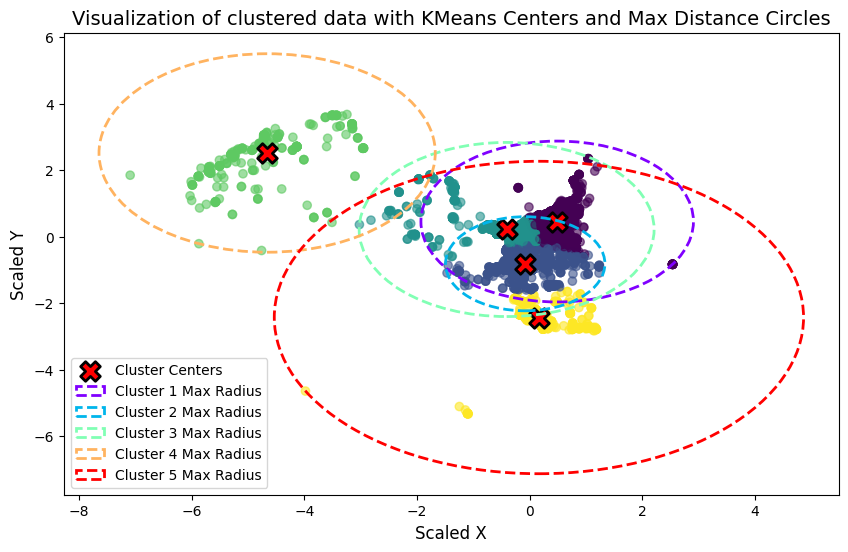

In [30]:

# Define a list of colors for the circles
circle_colors = plt.cm.rainbow(np.linspace(0, 1, len(spatial_radii)))

# Create the scatter plot for clusters
plt.figure(figsize=(10, 6))
plt.scatter(scaled_spatial_data['normLatitude'], scaled_spatial_data['normLongitude'], 
            c=df['SpatialCluster'], cmap='viridis', marker='o', alpha=0.6)

# Plot the cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', 
            edgecolors='k', linewidths=2, label='Cluster Centers')

# Plot circles around each cluster center with different colors
for i, radius in enumerate(spatial_radii):
    circle = plt.Circle((centers[i, 0], centers[i, 1]), radius, color=circle_colors[i], 
                        fill=False, linestyle='--', linewidth=2, label=f'Cluster {i+1} Max Radius')
    plt.gca().add_patch(circle)

# Set plot labels and title
plt.title('Visualization of clustered data with KMeans Centers and Max Distance Circles', fontsize=14)
plt.xlabel('Scaled X', fontsize=12)
plt.ylabel('Scaled Y', fontsize=12)
plt.legend()
plt.show()

In [44]:
text_data = df[['text']]
text_data.head()

,text
0,World's #Deadliest Elite Special Forces In #Ma...
1,Yoooo my substitute is extremely attractive �?😛
2,Stopped for speeding at an invisible crosswalk...
3,The Spring Break is upon us. https://t.co/6JK2...
4,I can't believe I saw Abel twice within 6 mont...


In [45]:
text_data['totalwords'] = text_data['text'].str.count(' ') + 1
text_data.describe

C:\Users\Kostas\AppData\Local\Temp\ipykernel_5316\2307666330.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  text_data['totalwords'] = text_data['text'].str.count(' ') + 1


<bound method NDFrame.describe of                                                    text  totalwords
0     World's #Deadliest Elite Special Forces In #Ma...           9
1       Yoooo my substitute is extremely attractive �?😛           7
2     Stopped for speeding at an invisible crosswalk...           9
3     The Spring Break is upon us. https://t.co/6JK2...           7
4     I can't believe I saw Abel twice within 6 mont...          12
...                                                 ...         ...
9995  Kudos 2 @BronwynBeightol 4 capturing the tapes...          13
9996                             @jsepulveda38 really?😻           2
9997  https://t.co/FX0IzS5JFd and just back when I w...          12
9998  I hate when niggas be like "tonight finna be a...          19
9999  �So much weirdness dry wit &amp; je ne sais qu...          18

[10000 rows x 2 columns]>

In [46]:
# Keeps the rows that totalwords > 3
text_data=text_data.loc[text_data['totalwords'] >= 3]
text_data.head()

,text,totalwords
0,World's #Deadliest Elite Special Forces In #Ma...,9
1,Yoooo my substitute is extremely attractive �?😛,7
2,Stopped for speeding at an invisible crosswalk...,9
3,The Spring Break is upon us. https://t.co/6JK2...,7
4,I can't believe I saw Abel twice within 6 mont...,12


In [47]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Kostas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Kostas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [48]:

# Custom function to remove stopwords
def remove_stopwords_nltk(text):
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(text)
    filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
    return filtered_sentence

# Apply this custom function to your DataFrame
text_data['text'] = text_data['text'].apply(lambda x: remove_stopwords_nltk(x))

C:\Users\Kostas\AppData\Local\Temp\ipykernel_5316\557391467.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  text_data['text'] = text_data['text'].apply(lambda x: remove_stopwords_nltk(x))


In [49]:
text_data.head()

,text,totalwords
0,"[World, 's, #, Deadliest, Elite, Special, Forc...",9
1,"[Yoooo, substitute, extremely, attractive, �, ...",7
2,"[Stopped, speeding, invisible, crosswalk, ...,...",9
3,"[Spring, Break, upon, us, ., https, :, //t.co/...",7
4,"[ca, n't, believe, saw, Abel, twice, within, 6...",12


In [50]:
# text_sentences = [line.split() for line in text_data.text]
# print(text_sentences)
def getEmbeddings(sentence):
    vec =[]
    for word in sentence:
        try:
            vec.append(word_vectors[word])  
        except:
            pass
    return np.mean(np.array(vec), axis=0)
text_data['embs'] = text_data.text.apply(lambda sentence: getEmbeddings(sentence))


c:\Users\Kostas\Desktop\Data Science\.venv\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Kostas\Desktop\Data Science\.venv\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Kostas\AppData\Local\Temp\ipykernel_5316\2823205325.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  text_data['embs'] = text_data.text.apply(lambda sentence: getEmbeddings(sentence))


In [51]:
text_data.head()

,text,totalwords,embs
0,"[World, 's, #, Deadliest, Elite, Special, Forc...",9,"[0.39251286, 0.16711856, 0.13518886, -0.008051..."
1,"[Yoooo, substitute, extremely, attractive, �, ...",7,"[0.1401175, -0.30772474, 0.08958799, 0.4614024..."
2,"[Stopped, speeding, invisible, crosswalk, ...,...",9,"[0.04792, 0.020758703, -0.06508, 0.24670202, 0..."
3,"[Spring, Break, upon, us, ., https, :, //t.co/...",7,"[0.49833402, 0.1804026, -0.11133798, 0.1055339..."
4,"[ca, n't, believe, saw, Abel, twice, within, 6...",12,"[0.27645218, 0.31319204, 0.044820108, -0.02372..."


In [52]:
from sklearn.decomposition import PCA
text_data['emb_dim'] = text_data['embs'].apply(lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0)
text_data = text_data[text_data['emb_dim'] == 100]
embeddings_matrix = np.vstack(text_data['embs'].values)

pca = PCA(n_components=2)

# Apply PCA to the valid embeddings
pca_data = pca.fit_transform(embeddings_matrix)

C:\Users\Kostas\AppData\Local\Temp\ipykernel_5316\4107982574.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  text_data['emb_dim'] = text_data['embs'].apply(lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0)


In [60]:
pca_data[:2]

array([[ 1.693139  ,  0.73871577],
       [-1.1266754 ,  1.3057396 ]], dtype=float32)

In [54]:
kmeans = KMeans(n_clusters=5, random_state=42)
text_data['TextualCluster'] = kmeans.fit_predict(pca_data)
# Extract cluster centers
centers = kmeans.cluster_centers_
spatial_radii = []
# Verify that the data and cluster centers are aligned
print("Cluster Centers:\n", centers)

# Loop through each cluster and check distances
for i in range(5):
    cluster_points = pca_data[text_data['TextualCluster'] == i]

    # Calculate the distances
    distances = np.linalg.norm(cluster_points - centers[i], axis=1)
    # print(f"Distances for Cluster {i}:\n", distances[:2])  # Show first 5 distances to check
    
    # Calculate the maximum distance
    max_distance = max(distances)
    # print(f"Max Distance for Cluster {i}: {max_distance}")
    spatial_radii.append(max_distance)

print (spatial_radii)

Cluster Centers:
 [[-0.18997808 -0.00643846]
 [ 1.52861     0.09698264]
 [-1.4856434  -0.01673618]
 [ 0.8099845  -1.442901  ]
 [ 0.6710267   1.0243129 ]]
[1.5650599, 1.7697601, 2.21681, 2.0167234, 2.6989722]


In [55]:
text_data['TextualCluster'].head()

0    1
1    2
2    4
3    4
4    2
Name: TextualCluster, dtype: int32

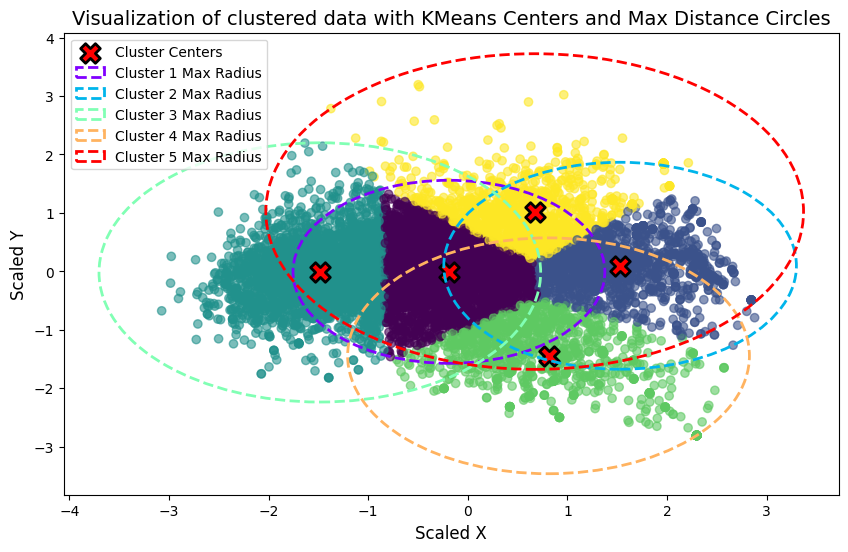

In [66]:

# Define a list of colors for the circles
circle_colors = plt.cm.rainbow(np.linspace(0, 1, len(spatial_radii)))

# Create the scatter plot for clusters
plt.figure(figsize=(10, 6))
plt.scatter(pca_data[:,0], pca_data[:,1], 
            c=text_data['TextualCluster'], cmap='viridis', marker='o', alpha=0.6)

# Plot the cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', 
            edgecolors='k', linewidths=2, label='Cluster Centers')

# Plot circles around each cluster center with different colors
for i, radius in enumerate(spatial_radii):
    circle = plt.Circle((centers[i, 0], centers[i, 1]), radius, color=circle_colors[i], 
                        fill=False, linestyle='--', linewidth=2, label=f'Cluster {i+1} Max Radius')
    plt.gca().add_patch(circle)

# Set plot labels and title
plt.title('Visualization of clustered data with KMeans Centers and Max Distance Circles', fontsize=14)
plt.xlabel('Scaled X', fontsize=12)
plt.ylabel('Scaled Y', fontsize=12)
plt.legend()
plt.show()